# DAY 2 — 배터리 수명 예측 실습


| 단계 | 하는 일 | 핵심 질문 |
|---|---|---|
| 1. 데이터 준비 | MAT 읽기·제외 기준·GZ 생성 | 원자료가 셀별 자료로 어떻게 바뀌는가? |
| 2. 데이터 확인 | 크기·결측·제외 기준 확인 | 어떤 셀을 사용할까? |
| 3. Feature Creation | 초기 평균·두 파생변수·CSV 생성 | 원자료로 어떤 입력을 만들까? |
| 4. Target 설정 | X와 y의 역할 정하기 | 무엇으로 무엇을 예측할까? |
| 5. 데이터 분할 | 개발·검증·Test 구분 | 어떤 데이터로 선택하고 평가할까? |
| 6. Feature Transformation | 대치·표준화·로그 변환 | 변환 기준은 어디에서 계산할까? |
| 7. 한 모델 학습 | fit → predict → 평가 연습 | 모델을 학습한다는 것은 무엇인가? |
| 8. 후보 비교 | 모델·입력·설정 비교 | 어떤 조합을 선택할까? |
| 9. Train CV | 선택 과정까지 검증 | 여러 후보 중 고르는 과정도 믿을 만할까? |
| 10. 최종 학습 | 개발 데이터에서 최종 선택·고정 | Test 전에 무엇을 확정할까? |
| 11. 평가 | Valid·Batch 2·Batch 3 예측 | 새로운 셀에서도 잘 맞을까? |
| 12. 결과 해석 | 성능 표·그래프·오류 확인 | 어디에서 오차가 커질까? |
| 13. 정리·연습 | 배운 내용 확인 | 직접 설명하고 바꿔 볼 수 있을까? |

**분석 단위:** 배터리 셀 1개. **예측 시점:** 100사이클 종료. **예측 대상:** 전체 `cycle_life`.
배터리 내부 기록은 시계열이지만 이번 모델은 셀별 요약 변수를 이용한 회귀다.
월별 승객 예시의 다음 달 타깃·시간순 분할·Lag 변수를 그대로 가져오지 않는다.

이전 실험과 같은 후보·분할을 읽기 쉽게 다시 실행한다. Test 점수를 보고 새 모델을 찾는 실험은 아니다.
최종 SVR 결과와 수치가 일치하는지 확인했다. 노트북에서 계산하는 값과 기존 기록을 구분하여 표시한다.

전체 흐름: **MAT → 품질 기준 → 초기 특징·파생변수 → 중간 파일 저장 → 그룹 분할 → 학습 → 평가**.


# 1. 데이터 준비 — MAT 원자료부터 시작
## 1-1. 라이브러리와 경로 설정

`h5py`로 MATLAB v7.3(HDF5) 파일을 읽는다. `numpy`는 수치 계산, `pandas`는 셀별 표를 만든다.
**아래 RAW_DIR만 실제 MAT 폴더로 설정한다.** 기존 CSV·GZ가 없어도 실행된다.

폴더 구조를 정리해 결과는 results/, 그래프는 results/figures/에 저장한다.
아래 일부 저장된 출력의 이전 경로는 당시 실행 기록이며, 재실행하면 새 경로를 사용한다. 학습 계산과 결과 수치는 그대로다.


In [1]:
from pathlib import Path
import gzip
import json
import hashlib
import re
import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib



In [ ]:
RAW_DIR = Path('/Users/jang/Documents/data-science/skala-ds/90-MiniProject/data/data-30')
PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'results'
SAVE_DIR = DATA_DIR
FIGURE_DIR = SAVE_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
TARGET_MAPE = 9.1
print('MAT 위치:', RAW_DIR)
print('생성 파일 위치:', SAVE_DIR)


MAT 위치: /Users/jang/Documents/data-science/skala-ds/90-MiniProject/data/data-30
생성 파일 위치: /Users/jang/Documents/Codex/2026-10-01/goe/skala-min_project/results


## 1-2. MAT 파일과 처리 기준 확인

MAT 원자료 세 파일은 합쳐 약 8GB다. 이 노트북에서 직접 읽고 필요한 셀별 정보를 추출한다.
**한 행 = 셀 1개**, `cycle_life`는 해당 셀의 실제 수명이다.

`model_eligible`은 원자료에 있던 변수가 아니라, 데이터 정리 과정에서 추가한 **모델 사용 여부 표시**다.
`True`는 사용, `False`는 제외를 뜻하며 모델의 입력 X에는 넣지 않는다.

| 입력 MAT 파일 날짜 | 과제 배치 |
|---|---|
| `2017-05-12` | Batch 1 |
| `2018-02-20` | Batch 2 |
| `2018-04-12` | Batch 3 |

CSV는 3단계에서, 분할 목록은 5단계에서 생성한다. GZ는 1-6에서 추출한 정보를 압축 저장한다. `2018-04-03_varcharge` 파일은 사용하지 않는다.

### 모델 사용 여부를 정한 기준

제공 파일의 수명 값과 [저자의 데이터 정제 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/Load%20Data.ipynb)를 참고하여 아래 기준을 적용했다.

| 기준 | 제외 이유 | 이번 데이터에서의 처리 |
|---|---|---|
| 수명 값 결측·무효 | 정답인 `cycle_life`가 NaN·무한대·0 이하이면 학습·평가할 수 없음 | Batch 2의 8개, Batch 3의 2개를 **표 생성 전에 제거** |
| 다른 파일에서 이어서 실험한 셀 | 현재 파일만으로는 전체 수명 기록이 완전하지 않음 | `b1c0~b1c4`는 EDA에 유지하고 `model_eligible=False` |
| 용량 80%까지 도달하지 않은 셀 | 종료 전 중단된 실험 기록을 확정 수명으로 쓰지 않기 위함 | 저자 목록의 `b1c8, b1c10, b1c12, b1c13, b1c22`를 EDA에 유지하고 `False` |
| 저자가 잡음 채널로 제외한 셀 | 측정 기록의 신뢰성 문제 | 저자 목록 중 표에 남은 `b3c2, b3c37, b3c42, b3c43`을 EDA에 유지하고 `False` |

**출처 :** 저자 노트북의 실행 번호 `[2]`는 Batch 1의 용량 80% 미도달 셀을, `[9]`는 Batch 3의 잡음 채널을 삭제한다. 저자의 Batch 3 목록에는 `b3c23, b3c32`도 있지만, 이번 파일에서는 수명 값이 없어 먼저 제거했다.

이어진 실험을 합치는 저자의 방식은 이번에 제공된 Batch 2 파일과 그대로 연결할 수 없어서 임의로 합치지 않았다. 따라서 Batch 1의 해당 5개는 현재 파일 기준으로 모델에서 제외했다.

이 표시는 새로운 품질 점수를 계산한 결과가 아니다. **모든 셀의 잡음 크기나 80% 도달 여부를 새로 계산한 것이 아니라**, 수명 값 검사와 정제 목록을 적용했다. 수명이 짧거나 예측 오차가 크다는 이유로 셀을 제외하지 않았다.

아래 1-5 코드에서 직접 기준을 적용하고 `data_audit.csv`에 사유를 저장한다. 최종적으로 EDA 표에는 129개, 모델 대상에는 115개 셀이 남는다.


In [2]:
MAT_FILES = {
    1: '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    2: '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    3: '2018-04-12_batchdata_updated_struct_errorcorrect.mat'
}
for batch_number, filename in MAT_FILES.items():
    mat_path = RAW_DIR / filename
    if not mat_path.exists():
        raise FileNotFoundError(f'Batch {batch_number} MAT 파일을 찾을 수 없습니다: {mat_path}')
    print(f'Batch {batch_number}: {mat_path.name}')

# 원본 필드가 실제로 있는지 확인한다. r은 읽기 전용이다.
with h5py.File(RAW_DIR / MAT_FILES[1], 'r') as mat:
    print('원본 batch 필드:', list(mat['batch'].keys()))
    print('Batch 1 원시 셀 개수:', mat['batch']['cycle_life'].size)


Batch 1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat
Batch 2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat
Batch 3: 2018-04-12_batchdata_updated_struct_errorcorrect.mat
원본 batch 필드: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
Batch 1 원시 셀 개수: 46


## 1-3. MATLAB 참조를 따라 값 읽기

이 MAT는 셀 값이 저장된 위치를 가리키는 **참조**를 담고 있다.
`mat[참조]`로 실제 값에 접근하고 `[()]`로 읽는다. `ravel()`은 배열을 한 줄로 편다.
아래 작은 함수들은 파일 형식을 읽기 위한 도구다. 새 측정값을 만드는 함수가 아니다.


In [3]:
def read_array(mat, reference_table, cell_index):
    reference = reference_table[cell_index, 0]
    return mat[reference][()].ravel()

def read_capacity_curve(mat, cycle_group, cycle_number):
    references = cycle_group['Qdlin']
    if cycle_number > references.shape[0]:
        return None
    dataset = mat[references[cycle_number - 1, 0]]
    if dataset.attrs.get('MATLAB_empty', False):
        return None
    return dataset[()].ravel().tolist()


### 셀 하나를 사전으로 정리

수명·정책·summary·전압 격자와 2/10/100사이클의 Qdlin을 원자료에서 읽는다.
`cell_id`, `batch`, `raw_index`는 추출 과정에서 식별용으로 붙인다.
시간별 모든 측정값을 복사하지 않고 이번 분석에 필요한 원본 필드를 선택한다.


In [4]:
def read_battery(mat, batch_number, cell_index):
    batch_group = mat['batch']
    summary_group = mat[batch_group['summary'][cell_index, 0]]
    cycle_group = mat[batch_group['cycles'][cell_index, 0]]
    policy_codes = read_array(mat, batch_group['policy_readable'], cell_index)
    return {
        'cell_id': f'b{batch_number}c{cell_index}',
        'batch': batch_number,
        'raw_index': cell_index,
        'cycle_life': float(read_array(mat, batch_group['cycle_life'], cell_index)[0]),
        'policy': ''.join(chr(int(x)) for x in policy_codes),
        'summary': {key: summary_group[key][()].ravel().tolist() for key in summary_group.keys()},
        'Vdlin': read_array(mat, batch_group['Vdlin'], cell_index).tolist(),
        'Qdlin': {str(cycle): read_capacity_curve(mat, cycle_group, cycle) for cycle in [2, 10, 100]}
    }


## 1-4. 세 MAT에서 셀별 정보 추출

파일을 읽기 전용으로 하나씩 연다. 셀을 순서대로 꺼내 `raw_batteries` 리스트에 담는다.
원시 개수는 Batch 1/2/3 = 46/47/46, 합계 139개다.


In [5]:
raw_batteries = []
raw_counts = {}
for batch_number, filename in MAT_FILES.items():
    with h5py.File(RAW_DIR / filename, 'r') as mat:
        count = mat['batch']['cycle_life'].size
        raw_counts[batch_number] = count
        for cell_index in range(count):
            raw_batteries.append(read_battery(mat, batch_number, cell_index))
    print(f'Batch {batch_number}: {count}개 셀 추출 완료')

assert list(raw_counts.values()) == [46, 47, 46]
pd.DataFrame(raw_counts.items(), columns=['batch', 'raw_cells'])


Batch 1: 46개 셀 추출 완료
Batch 2: 47개 셀 추출 완료
Batch 3: 46개 셀 추출 완료


,batch,raw_cells
0,1,46
1,2,47
2,3,46


## 1-5. 모델 제외 목록 만들기

후속 실험 5개와 저자 정제 목록을 코드에 명시한다. 영어 이유는 이전 기록과의 일치를 위해 유지한다.
Batch 3의 저자 제외 6개 중 수명 결측 2개는 다음 셀에서 먼저 제거한다.


In [6]:
exclusion_reasons = {}
for index in [0, 1, 2, 3, 4]:
    exclusion_reasons[f'b1c{index}'] = 'continuation recorded elsewhere; this file alone does not provide complete life'
for index in [8, 10, 12, 13, 22]:
    exclusion_reasons[f'b1c{index}'] = 'author identifies EOL not reached'
for index in [2, 23, 32, 37, 42, 43]:
    exclusion_reasons[f'b3c{index}'] = 'author excludes noisy/incomplete cell'

pd.DataFrame(exclusion_reasons.items(), columns=['cell_id', 'model_exclusion_reason'])


,cell_id,model_exclusion_reason
0,b1c0,continuation recorded elsewhere; this file alone does not provide complete life
1,b1c1,continuation recorded elsewhere; this file alone does not provide complete life
2,b1c2,continuation recorded elsewhere; this file alone does not provide complete life
3,b1c3,continuation recorded elsewhere; this file alone does not provide complete life
4,b1c4,continuation recorded elsewhere; this file alone does not provide complete life
5,b1c8,author identifies EOL not reached
6,b1c10,author identifies EOL not reached
7,b1c12,author identifies EOL not reached
8,b1c13,author identifies EOL not reached
9,b1c22,author identifies EOL not reached


### 수명 값 확인 → model_eligible 지정

수명이 NaN/무한대/0 이하인 셀은 정답을 알 수 없으므로 먼저 제거한다.
나머지는 EDA에 남기고 제외 목록에 있으면 `False`, 없으면 `True`를 붙인다.


In [7]:
batteries = []
audit_rows = []
for battery in raw_batteries:
    cell_id = battery['cell_id']
    life = battery['cycle_life']
    if not np.isfinite(life) or life <= 0:
        audit_rows.append({'cell_id': cell_id, 'action': 'exclude_target_eda_and_model',
                           'reason': 'missing or invalid cycle_life'})
        continue
    reason = exclusion_reasons.get(cell_id, '')
    battery['model_eligible'] = not bool(reason)
    battery['model_exclusion_reason'] = reason
    if reason:
        audit_rows.append({'cell_id': cell_id, 'action': 'keep_raw_EDA_exclude_model', 'reason': reason})
    batteries.append(battery)

assert len(batteries) == 129
assert sum(b['model_eligible'] for b in batteries) == 115
df = pd.DataFrame([{key: b[key] for key in ['cell_id', 'batch', 'cycle_life', 'policy',
                                           'model_eligible', 'model_exclusion_reason']} for b in batteries])
df.head()


,cell_id,batch,cycle_life,policy,model_eligible,model_exclusion_reason
0,b1c0,1,1190.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life
1,b1c1,1,1179.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life
2,b1c2,1,1177.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life
3,b1c3,1,1226.0,4C(80%)-4C,False,continuation recorded elsewhere; this file alone does not provide complete life
4,b1c4,1,1227.0,4C(80%)-4C,False,continuation recorded elsewhere; this file alone does not provide complete life


## 1-6. 추출한 셀별 정보를 GZ로 저장

위에서 읽고 정리한 `batteries`를 JSON으로 바꿔 GZ 압축 저장한다.
파일은 실행 속도·공유를 위한 중간 저장물이다.


In [8]:
cache_path = SAVE_DIR / 'three_batches_eda_data.json.gz'
with gzip.open(cache_path, 'wt', encoding='utf-8') as file:
    json.dump(batteries, file)
data_audit = pd.DataFrame(audit_rows)
data_audit.to_csv(SAVE_DIR / 'data_audit.csv', index=False)
print('GZ 생성:', cache_path)
print('제외 사유 기록:', SAVE_DIR / 'data_audit.csv')


GZ 생성: /Users/jang/Documents/Codex/2026-10-01/goe/outputs/DAY2-learning/three_batches_eda_data.json.gz
제외 사유 기록: /Users/jang/Documents/Codex/2026-10-01/goe/outputs/DAY2-learning/data_audit.csv


## 1-7. 변수 이름의 출처 — 원자료와 코드 변수 구분

**`Vdlin`은 원자료에 있는 필드이고, `voltage`는 그 값을 꺼내 담은 코드 변수다.** 이름을 새로 붙였다고 모두 새로운 모델 입력이 되는 것은 아니다.

| 이름 | 출처·역할 | 이번 코드에서의 의미 |
|---|---|---|
| `cycle_life` | MAT 원자료 | 실제 수명; 예측할 정답 y |
| `policy_readable` → `policy` | 원자료 필드의 문자열 변환·이름 정리 | 충전 프로토콜 설명 |
| `summary` | MAT 원자료 | 사이클별 용량·온도·IR·충전 시간 등 요약 기록 |
| `Vdlin` | **MAT 원자료** | 방전 용량을 비교하는 전압 격자. 이번 파일은 3.5→2.0V의 1,000점 |
| `Qdlin` | **MAT 원자료의 사이클별 필드** | `Vdlin` 각 전압에 대응하도록 보간된 방전 용량 |
| `voltage` / `v` | `Vdlin`을 꺼낸 코드 변수 | `np.asarray(...)`로 만든 계산용 배열; 새 전압 측정값이 아님 |
| `q10` / `q100` | `Qdlin`에서 특정 사이클을 꺼낸 코드 변수 | 10번째 / 100번째 사이클 용량 배열 |
| `delta_q` / `q_delta` | 직접 계산 | 같은 전압에서 `q100 − q10`; 1,000개의 차이 값 |
| `mid_band` / `low_band` | 직접 만든 조건 배열 | 두 전압 구간에 해당하는 위치를 True/False로 표시 |
| `dq_log_variance` / `dq_band_gap` | 곡선에서 계산한 추가 특징 | 1,000개 차이 값을 셀당 숫자 두 개로 요약 |
| `cell_id` / `batch` | 추출 과정에서 추가 | 셀 식별·배치 구분; 모델 입력으로 사용하지 않음 |
| `model_eligible` | 정리 과정에서 추가 | 행을 사용할지 결정하는 표시; 품질 기준은 1-2 참고 |

예를 들어 `voltage[0]`이 3.5V일 때 `q10[0]`, `q100[0]`은 모두 그 3.5V에서의 용량이다. 동일한 위치끼리 빼서 `delta_q[0]`을 만든다. 원래 시간별 전압 기록을 행 번호만으로 비교하는 방식이 아니다.

```python
voltage = np.asarray(example['Vdlin'])  # 원자료 전압 격자를 배열로 꺼냄
q10 = np.asarray(example['Qdlin']['10'])  # 10번째 사이클 용량
q100 = np.asarray(example['Qdlin']['100'])  # 100번째 사이클 용량
delta_q = q100 - q10  # 전압별 용량 차이 계산
```

**3단계에서 만들 CSV의 기본 후보도 출처가 다르다.** `C1`, `C2`, `SOC_switch`는 충전 프로토콜 문자열을 숫자로 분리한 값이고, `mean_chargetime`은 초기 2~100사이클 충전 시간의 평균이다. `mean_QD`, `mean_IR`, `mean_Tavg`, `mean_Tmax`도 초기 측정값을 요약한 평균이며, 이번 DAY 2 입력 후보에는 넣지 않았다.

`X_train_scaled`, `best_model`, `predictions`처럼 뒤에 나오는 이름은 각각 변환한 표, 학습된 모델, 예측 결과다. 원자료의 측정 변수나 추가 파생변수가 아니다.
코드에 등장하는 나머지 이름은 [DAY2-변수설명.md](../docs/DAY2-변수설명.md)에 역할별로 모두 정리했다.


# 2. 데이터 확인
## 2-1. 컬럼·결측값·수명 분포 확인

지금 df에는 원자료에서 읽은 수명·정책·식별 정보와 사용 여부가 있다.
파생변수는 다음 3단계에서 직접 계산하여 열을 추가한다.
`info()`는 자료형, `describe()`는 범위·중심값, `isna().sum()`은 결측 개수를 보여준다.


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cell_id                 129 non-null    str    
 1   batch                   129 non-null    int64  
 2   cycle_life              129 non-null    float64
 3   policy                  129 non-null    str    
 4   model_eligible          129 non-null    bool   
 5   model_exclusion_reason  129 non-null    str    
dtypes: bool(1), float64(1), int64(1), str(3)
memory usage: 5.3 KB


In [10]:
df[['cycle_life']].describe().round(3)


,cycle_life
count,129.000
mean,833.690
std,314.973
min,392.000
25%,559.000
50%,828.000
75%,1017.000
max,1935.000


In [11]:
df[['cycle_life', 'policy', 'model_eligible']].isna().sum().to_frame('결측 개수')


,결측 개수
cycle_life,0
policy,0
model_eligible,0


## 2-2. EDA 셀과 모델 셀 구분

EDA에는 수명 라벨이 유효한 셀이 129개 있다.
모델에는 종료 수명이 불완전하거나 기록 품질 문제가 있는 셀을 제외한 115개를 사용한다.
**짧은 수명이나 큰 예측 오차를 이유로 제외하지 않는다.**

Batch 1은 2017-05-12, Batch 2는 2018-02-20, Batch 3는 2018-04-12 파일이다.


In [12]:
cell_counts = df.groupby('batch').agg(
    EDA_cells=('cell_id', 'size'),
    model_cells=('model_eligible', 'sum')
)
cell_counts


,EDA_cells,model_cells
batch,,
1,46,36
2,39,39
3,44,40


# 3. Feature Creation — 파생변수 생성
## 3-1. 한 셀의 ΔQ(V)부터 이해하기

`Q10`과 `Q100`은 같은 전압에서의 10번째·100번째 사이클 방전 용량이다.
`delta_q = Q100 - Q10`은 초기 사이클 사이에서 용량 곡선이 얼마나 달라졌는지 보여준다.
캐시의 `Qdlin`은 전압에 맞춰 보간한 방전 용량이다.

### 왜 ΔQ를 만들었을까?

**한 시점의 용량이 비슷해도, 초기 사이클 동안의 변화는 셀마다 다를 수 있다**고 생각했다.
충전 조건은 셀에 어떤 실험을 했는지 알려주지만, ΔQ는 그동안 셀에서 관측된 변화를 보여준다.
초기 변화가 전체 수명과 연결되는지 확인하기 위해 같은 셀의 두 시점 용량을 뺐다.

- **변화에 집중:** Q10 또는 Q100만 보는 대신 10→100사이클 사이에 달라진 정도를 본다.
- **전압별 차이 확인:** 용량 변화가 어느 전압 구간에서 큰지 확인한다. 두 원래 곡선이 거의 겹쳐도 차이 곡선에서는 작은 변화가 보인다.
- **예측 시점 준수:** 이번 예측은 100사이클 종료 시점이므로 Q10과 Q100을 사용할 수 있다. 100사이클 이후 정보는 쓰지 않는다.

아래 그림의 왼쪽은 원래 두 곡선, 오른쪽은 같은 전압끼리 뺀 ΔQ다.
오른쪽이 음수이면 Q100이 Q10보다 작다는 뜻이다. **한 셀의 그림은 계산을 설명하는 예시이며, 수명과의 관계나 성능 향상을 증명하지는 않는다.**

ΔQ는 1,000개의 값이다. 이를 그대로 모두 입력하기보다 작은 셀 표본에 맞춰 다음 단계에서 두 숫자로 요약한다.


In [13]:
eligible_batteries = [b for b in batteries if b['model_eligible']]
example = eligible_batteries[0]
voltage = np.asarray(example['Vdlin'])
q10 = np.asarray(example['Qdlin']['10'])
q100 = np.asarray(example['Qdlin']['100'])
delta_q = q100 - q10

print('예시 셀:', example['cell_id'])
print('전압 점 개수:', len(voltage))
pd.DataFrame({'V': voltage, 'Q10': q10, 'Q100': q100, 'delta_Q': delta_q}).head()


예시 셀: b1c5
전압 점 개수: 1000


,V,Q10,Q100,delta_Q
0,3.500000,-0.000461,-0.000224,0.000237
1,3.498498,-0.000421,-0.000195,0.000226
2,3.496997,-0.000382,-0.000167,0.000216
3,3.495495,-0.000345,-0.000140,0.000205
4,3.493994,-0.000309,-0.000114,0.000195


learning-cell-26-display:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


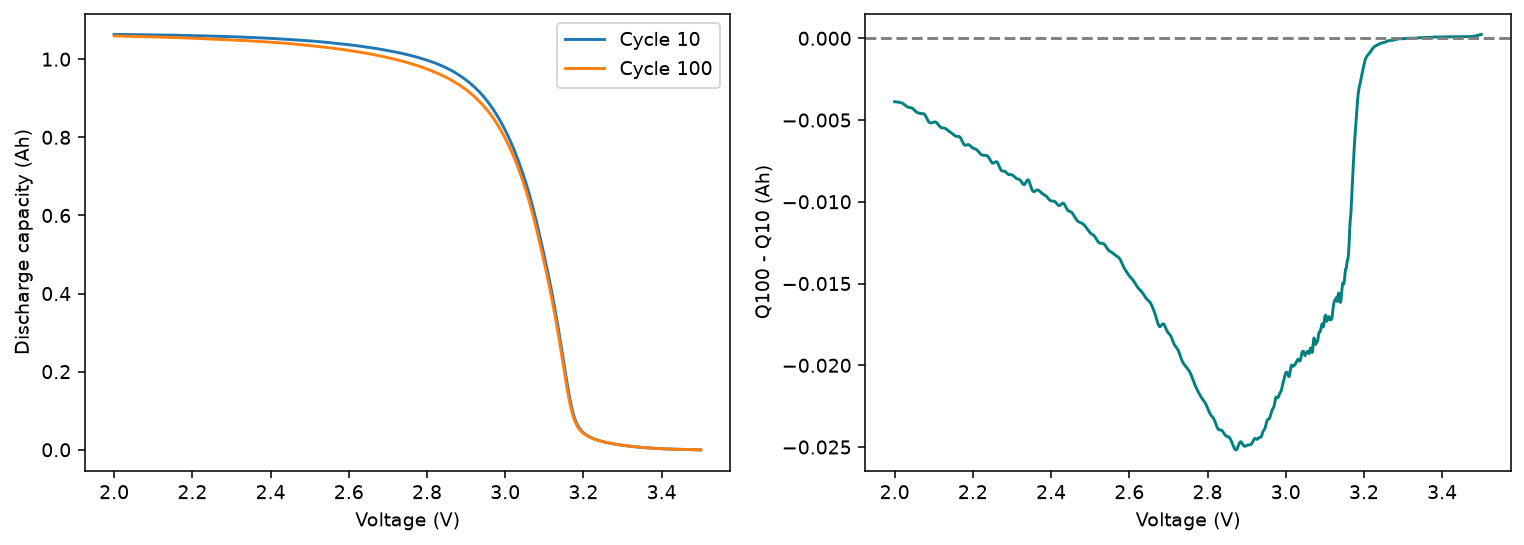

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(voltage, q10, label='Cycle 10')
axes[0].plot(voltage, q100, label='Cycle 100')
axes[0].set(xlabel='Voltage (V)', ylabel='Discharge capacity (Ah)')
axes[0].legend()
axes[1].plot(voltage, delta_q, color='teal')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set(xlabel='Voltage (V)', ylabel='Q100 - Q10 (Ah)')
plt.tight_layout()
plt.show()


## 3-2. 곡선에서 두 숫자 만들기

추가 파생변수는 **로그 분산과 전압 구간 차이, 두 개만** 비교한다.
변수를 만드는 이유는 곡선의 정보를 적은 수의 입력으로 요약하고, 실제 예측에 도움이 되는지 확인하기 위해서다.

### 파생변수 1. ΔQ 로그 분산 (`dq_log_variance`)

**정의:** `log10(var(delta_q))`, 분산은 `ddof=0`으로 계산한다.

**만든 이유:** 전압 전체에서 비슷하게 변화한 셀과 특정 구간에서 유독 크게 변화한 셀을 구분하고 싶었다.
분산은 ΔQ의 값들이 평균 주변에 얼마나 퍼져 있는지 나타낸다.
따라서 단순한 평균 변화량과 달리 **전압에 따른 변화의 불균일한 정도**를 숫자 하나로 요약한다.
분산이 작은 양수일 수 있으므로 `log10`으로 값의 범위를 다루기 쉽게 바꿨다.

**검증할 가설:** 이러한 초기 변화의 불균일성이 전체 수명을 설명하는 데 도움이 될 수 있다.
분산이 크면 무조건 수명이 짧다는 규칙을 미리 정한 것은 아니다.

### 파생변수 2. 전압 구간 차이 (`dq_band_gap`)

**정의:** `mean(ΔQ, 2.8≤V≤3.1) − mean(ΔQ, 2.0≤V≤2.5)`.

**만든 이유:** 전체 분산만 보면 변화가 어느 구간에 집중됐는지 알기 어렵다.
그래서 중간 전압 구간과 낮은 전압 구간의 평균 변화를 비교하여 **구간에 따른 곡선 형태 차이**를 추가로 표현하려 했다.

**검증할 가설:** 분산이 비슷한 셀이라도 두 구간의 변화 차이가 다르면 수명을 구분하는 데 추가 정보가 될 수 있다.
구간은 DAY 1에서 정한 범위를 그대로 사용했고 Test 점수를 보고 바꾸지 않았다.
해당 구간이 특정 물리 반응을 뜻한다고 확인한 것은 아니다.

### 만든 뒤 어떻게 판단할까?

이유가 그럴듯하다고 유용한 변수가 되는 것은 아니다.
10-3단계에서 **같은 SVR·로그 타깃으로 입력 조합별 개발 CV MAPE와 그래프를 비교**한다.
좋아지지 않는 변수는 최종 입력에서 제외한다. Valid·Test 점수로 변수를 선택하지 않는다.

여기서 `np.log10`은 **입력 변수** 변환이고, 이후 `np.log(cycle_life)`는 **타깃** 변환이다.


In [15]:
# 파생변수 1: ΔQ 곡선의 로그 분산
log_variance = np.log10(np.var(delta_q, ddof=0))

# 파생변수 2: 두 전압 구간의 평균 차이
mid_band = (voltage >= 2.8) & (voltage <= 3.1)
low_band = (voltage >= 2.0) & (voltage <= 2.5)
band_gap = delta_q[mid_band].mean() - delta_q[low_band].mean()

print('dq_log_variance:', log_variance)
print('dq_band_gap:', band_gap)


dq_log_variance: -4.178877963304522
dq_band_gap: -0.014708338516429617


## 3-3. 모든 EDA 셀의 두 파생변수 계산

EDA에 남긴 129개 셀에 같은 계산을 적용한다. 그중 모델 사용 셀은 115개다.
전압 격자·용량 배열 길이·유한값도 확인한다. 두 숫자를 표로 정리한다.


In [16]:
feature_rows = []
reference_voltage = np.asarray(eligible_batteries[0]['Vdlin'])
for battery in batteries:
    v = np.asarray(battery['Vdlin'])
    q10_array = np.asarray(battery['Qdlin']['10'])
    q100_array = np.asarray(battery['Qdlin']['100'])
    assert v.shape == q10_array.shape == q100_array.shape == (1000,)
    assert np.isfinite(q10_array).all() and np.isfinite(q100_array).all()
    np.testing.assert_allclose(v, reference_voltage, rtol=0, atol=1e-12)
    q_delta = q100_array - q10_array
    mid = (v >= 2.8) & (v <= 3.1)
    low = (v >= 2.0) & (v <= 2.5)
    feature_rows.append({
        'cell_id': battery['cell_id'],
        'dq_log_variance': np.log10(np.var(q_delta, ddof=0)),
        'dq_band_gap': q_delta[mid].mean() - q_delta[low].mean()
    })
calculated_features = pd.DataFrame(feature_rows).set_index('cell_id')
calculated_features.head()


,dq_log_variance,dq_band_gap
cell_id,,
b1c0,-5.014861,-0.007235
b1c1,-5.013960,-0.005582
b1c2,-4.737000,-0.007662
b1c3,-4.442613,-0.012596
b1c4,-4.647744,-0.009770


## 3-4. 초기 측정 평균과 충전 조건 계산

초기 2~100사이클 summary만 사용한다. 기존 DAY 1과 같은 값 처리 규칙이다.
QD 범위 0.01~1.32 밖은 결측 처리하고, 평균에는 양수만 포함하며 충전 시간은 60 이하를 사용한다.
이 규칙은 값 처리이며 셀 전체의 model_eligible 기준과 구분한다.


In [17]:
def summarize_initial_cycles(battery):
    summary = pd.DataFrame(battery['summary']).rename(
        columns={'QDischarge': 'QD', 'QCharge': 'QC'}
    )
    early = summary[summary['cycle'].between(2, 100)].copy()
    early.loc[~early['QD'].between(.01, 1.32), ['QD', 'QC']] = np.nan
    policy = battery['policy'].removesuffix('-newstructure')
    if not policy.endswith('C'):
        policy += 'C'
    row = {key: battery[key] for key in ['cell_id', 'batch', 'cycle_life',
                                        'model_eligible', 'model_exclusion_reason']}
    row['policy'] = policy
    for field in ['QD', 'IR', 'Tavg', 'Tmax', 'chargetime']:
        values = early[field].where(early[field] > 0)
        if field == 'chargetime':
            values = values.where(values <= 60)
        row['mean_' + field] = float(values.mean())
    return row


### 정책 문자열을 C1·C2·전환 SOC로 분리

예를 들어 `4.8C(80%)-4C`는 C1=4.8, SOC_switch=80, C2=4.0이다.
`re.fullmatch`는 문자열에서 이 형식의 세 숫자를 찾는다. 파생변수 두 개와 초기 요약값을 한 행으로 합친다.


In [18]:
def parse_charging_policy(policy):
    match = re.fullmatch(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C?', policy)
    if match is None:
        raise ValueError(f'충전 정책 형식을 확인하세요: {policy}')
    c1, switch, c2 = map(float, match.groups())
    return {'C1': c1, 'C2': c2, 'SOC_switch': switch}

feature_records = []
for battery in batteries:
    row = summarize_initial_cycles(battery)
    row.update(parse_charging_policy(row['policy']))
    row.update(calculated_features.loc[battery['cell_id']].to_dict())
    feature_records.append(row)
df = pd.DataFrame(feature_records)
df = df[['cell_id', 'batch', 'cycle_life', 'policy', 'model_eligible', 'model_exclusion_reason',
         'mean_QD', 'mean_IR', 'mean_Tavg', 'mean_Tmax', 'mean_chargetime',
         'C1', 'C2', 'SOC_switch', 'dq_log_variance', 'dq_band_gap']]
df.head()


,cell_id,batch,cycle_life,policy,model_eligible,model_exclusion_reason,mean_QD,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,C1,C2,SOC_switch,dq_log_variance,dq_band_gap
0,b1c0,1,1190.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life,1.075918,0.016643,31.603747,35.376748,13.384231,3.6,3.6,80.0,-5.014861,-0.007235
1,b1c1,1,1179.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life,1.081247,0.016922,31.330314,34.160655,13.374696,3.6,3.6,80.0,-5.013960,-0.005582
2,b1c2,1,1177.0,3.6C(80%)-3.6C,False,continuation recorded elsewhere; this file alone does not provide complete life,1.085371,0.016769,31.479584,34.544644,13.378886,3.6,3.6,80.0,-4.737000,-0.007662
3,b1c3,1,1226.0,4C(80%)-4C,False,continuation recorded elsewhere; this file alone does not provide complete life,1.084949,0.016311,29.942199,30.662263,12.053277,4.0,4.0,80.0,-4.442613,-0.012596
4,b1c4,1,1227.0,4C(80%)-4C,False,continuation recorded elsewhere; this file alone does not provide complete life,1.082844,0.016669,31.448884,34.382516,12.053314,4.0,4.0,80.0,-4.647744,-0.009770


## 3-5. 지금 만든 셀별 표를 CSV로 저장

여기에서 `cell_features.csv`를 처음 생성한다. 수명과 특징의 유효값을 점검하고 저장한다.
이 파일은 필수 시작 입력이 아니라, 위 계산으로 만들어진 중간 결과다.


In [19]:
assert df.groupby('batch').size().tolist() == [46, 39, 44]
assert not df['cell_id'].duplicated().any()
assert np.isfinite(df[['cycle_life', 'dq_log_variance', 'dq_band_gap']].to_numpy()).all()
feature_path = SAVE_DIR / 'cell_features.csv'
df.to_csv(feature_path, index=False)
print('CSV 생성:', feature_path)
print('EDA:', len(df), '/ 모델 대상:', df['model_eligible'].sum())
df[['C1', 'C2', 'SOC_switch', 'mean_chargetime', 'dq_log_variance', 'dq_band_gap']].describe().round(3)


CSV 생성: /Users/jang/Documents/Codex/2026-10-01/goe/outputs/DAY2-learning/cell_features.csv
EDA: 129 / 모델 대상: 115


,C1,C2,SOC_switch,mean_chargetime,dq_log_variance,dq_band_gap
count,129.000,129.000,129.000,129.000,129.000,129.000
mean,5.404,4.155,49.519,10.468,-3.917,-0.021
std,0.922,0.742,20.851,0.750,0.428,0.010
min,3.600,3.000,9.000,8.987,-5.099,-0.043
25%,4.800,3.600,31.000,10.043,-4.179,-0.030
50%,5.400,4.000,50.000,10.173,-4.000,-0.020
75%,5.600,4.600,67.000,10.796,-3.516,-0.015
max,8.000,6.000,80.000,13.384,-3.086,0.008


# 4. Target 설정 — X와 y 구분

**X:** 예측에 사용하는 정보. **y:** 맞혀야 하는 실제 수명.
회귀는 수명을 사이클 수로 예측하므로 임의의 장수명/단수명 경계를 정할 필요가 없다.

| 구분 | 변수 | 이유 |
|---|---|---|
| 기본 X 후보 | C1, C2, SOC_switch, mean_chargetime | 충전 조건과 초기 2~100사이클 평균 충전 시간 |
| 추가 X 후보 | dq_log_variance, dq_band_gap | 초기 용량 곡선의 변화 요약 |
| y | cycle_life | 전체 수명 |
| 제외 | cell_id, batch, policy | 식별·분할용 정보; policy는 충전 조건과 중복 |
| 제외 | 전체 기록 길이, 마지막 용량, Knee | 100사이클 시점에는 모르는 미래 정보 |
| 이번 후보에서 보류 | 온도, IR, 평균 QD | 이번 비교 범위를 제한; 항상 무의미하다는 뜻은 아님 |

### 보류한 변수와 그 근거

상관계수는 모델 대상 115개 셀에서 계산한 배치별 Pearson 상관이다.
전체 배치 EDA를 이미 본 상태에서 정한 후보 범위이며, 완전한 블라인드 Test는 아니다.
최종 후보 선택은 Batch 1 개발 자료로 한정했다.

| 변수 | 실제로 확인한 내용 | 이번 비교에서 보류한 이유 |
|---|---|---|
| 평균·최대 온도 (`mean_Tavg`, `mean_Tmax`) | 두 변수의 상관이 +0.865. 평균 온도와 수명의 상관은 Batch 1 −0.173, Batch 2 +0.425, Batch 3 −0.039 | 온도끼리 정보가 겹치고 수명과의 관계도 배치마다 달라, 작은 개발 표본에서 ΔQ와 충전 조건을 먼저 비교 |
| 평균 IR (`mean_IR`) | 평균 IR과 수명의 상관은 +0.224, −0.626, +0.201. 정리 후 Batch 2의 6개 셀에서 평균 IR이 결측이며 Batch 1에는 결측 없음 | 관계 방향과 측정 가용성이 배치마다 다름. IR을 추가한 후보와 결측 대치 효과는 후속 개발 실험으로 남김 |
| 초기 평균 방전 용량 (`mean_QD`) | 평균 QD와 수명의 상관은 +0.250, −0.333, +0.292. 초기 용량이 유지되거나 증가하는 셀도 많음 | 초기 평균값 하나의 배치 간 관계가 일정하지 않아, 전압별 변화인 ΔQ를 우선 검증 |

**보류는 성능이 나빠서 제외했다는 뜻이 아니다.** 이 변수들을 추가한 모델의 CV는 이번에 비교하지 않았다.
상관이 작거나 방향이 다르더라도 비선형 관계·다른 변수와의 조합은 도움이 될 수 있다.
후속 실험에서는 Batch 1 개발 자료에서 하나씩 추가해 같은 그룹 분할로 비교해야 한다.
근거: [배치별 상관 표](../results/correlations.csv), [초기 측정 품질 표](../results/input_quality.csv).


In [20]:
TARGET = 'cycle_life'
BASE_FEATURES = ['C1', 'C2', 'SOC_switch', 'mean_chargetime']
FEATURE_SETS = {
    'Charging only': BASE_FEATURES,
    'Variance only': ['dq_log_variance'],
    'Charging + variance': BASE_FEATURES + ['dq_log_variance'],
    'Charging + band gap': BASE_FEATURES + ['dq_band_gap'],
    'Charging + both': BASE_FEATURES + ['dq_log_variance', 'dq_band_gap']
}
pd.DataFrame({'입력 조합': FEATURE_SETS.keys(), '사용 변수': FEATURE_SETS.values()})


,입력 조합,사용 변수
0,Charging only,"[C1, C2, SOC_switch, mean_chargetime]"
1,Variance only,[dq_log_variance]
2,Charging + variance,"[C1, C2, SOC_switch, mean_chargetime, dq_log_variance]"
3,Charging + band gap,"[C1, C2, SOC_switch, mean_chargetime, dq_band_gap]"
4,Charging + both,"[C1, C2, SOC_switch, mean_chargetime, dq_log_variance, dq_band_gap]"


# 5. 데이터 분할 — 목록도 직접 생성
## 5-1. 충전 프로토콜 그룹 만들기

사용 가능한 셀만 남기고 C1·C2·SOC_switch 조합을 그룹 이름으로 만든다.
같은 실험 조건의 셀을 함께 나누기 위한 정보이며 모델의 입력은 아니다.


In [21]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

split_features = df[df['model_eligible']].copy()
split_features['protocol_group'] = split_features.apply(
    lambda row: f'{row.C1:g}C({row.SOC_switch:g}%)-{row.C2:g}C', axis=1
)
batch1 = split_features[split_features['batch'] == 1].reset_index(drop=True)
print('Batch 1 모델 셀:', len(batch1))
print('Batch 1 프로토콜:', batch1['protocol_group'].nunique())
batch1[['cell_id', 'protocol_group']].head()


Batch 1 모델 셀: 36
Batch 1 프로토콜: 20


,cell_id,protocol_group
0,b1c5,4.4C(80%)-4.4C
1,b1c6,4.8C(80%)-4.8C
2,b1c7,4.8C(80%)-4.8C
3,b1c9,5.4C(40%)-3.6C
4,b1c11,5.4C(50%)-3C


### 그룹 Hold-out 20% 만들기

20%는 셀 개수가 아닌 **프로토콜 그룹 비율**이다. 시드 42로 같은 분할을 재현한다.
Batch 1의 36개에서 개발 29개·Hold-out 7개가 나온다.


In [22]:
holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=.2, random_state=SEED)
development_idx, valid_idx = next(
    holdout_splitter.split(batch1, groups=batch1['protocol_group'])
)
development = batch1.iloc[development_idx].copy().reset_index(drop=True)
holdout = batch1.iloc[valid_idx].copy()
development['partition'] = 'Batch1-development-CV'
holdout['partition'] = 'Batch1-holdout-Valid'
print('개발:', len(development), '/ Hold-out:', len(holdout))


개발: 29 / Hold-out: 7


### 바깥 CV 폴드 번호와 Test 역할 지정

개발 29개에 그룹 5-fold 번호를 붙인다. Batch 2·3는 개발에 넣지 않는다.
이 분할 방식과 시드는 이전 실험을 그대로 재현한다.


In [23]:
development['cv_holdout_fold'] = 0
splitter = GroupKFold(n_splits=5)
for fold, (_, cv_idx) in enumerate(splitter.split(development, groups=development['protocol_group']), 1):
    development.loc[cv_idx, 'cv_holdout_fold'] = fold
holdout['cv_holdout_fold'] = pd.NA

batch2_test = split_features[split_features['batch'] == 2].copy()
batch2_test['partition'] = 'Batch2-final-Test'
batch2_test['cv_holdout_fold'] = pd.NA
batch3_test = split_features[split_features['batch'] == 3].copy()
batch3_test['partition'] = 'Batch3-EDA-only'
batch3_test['cv_holdout_fold'] = pd.NA

split_info = pd.concat([development, holdout, batch2_test, batch3_test], ignore_index=True)
split_info['cv_holdout_fold'] = split_info['cv_holdout_fold'].astype('Int64')
split_info = split_info[['cell_id', 'batch', 'protocol_group', 'partition', 'cv_holdout_fold']]
split_info.to_csv(SAVE_DIR / 'DAY2-split-manifest.csv', index=False)


### 만든 분할 목록을 셀별 표와 연결

CSV를 읽어 오는 것이 아니라 위에서 만든 split_info를 사용한다.
셀별 표의 원래 순서도 유지한다. 기존 코드와 같은 개발 셀·폴드가 만들어진다.


In [24]:
data = df.merge(
    split_info[['cell_id', 'protocol_group', 'partition', 'cv_holdout_fold']],
    on='cell_id', how='inner', validate='one_to_one'
)
assert len(data) == 115 and data['model_eligible'].all()
split_info.groupby(['partition', 'batch']).agg(
    cells=('cell_id', 'size'), protocols=('protocol_group', 'nunique')
)


,,cells,protocols
partition,batch,,
Batch1-development-CV,1,29,16
Batch1-holdout-Valid,1,7,4
Batch2-final-Test,2,39,9
Batch3-EDA-only,3,40,8


## 5-2. 개발·Hold-out·Test 나누기

| 이름 | 개수 | 역할 |
|---|---:|---|
| train / 개발 | 29 | Batch 1에서 모델 학습·CV 선택 |
| valid | 7 | Batch 1에서 따로 남긴 최종 검증 |
| test | 39 | Batch 2 필수 최종 평가 |
| test3 | 40 | Batch 3 추가 평가 |

분할 목록의 `Batch3-EDA-only`는 DAY 1에서 붙인 이름이다. 이번에는 **추가 Test**로 사용한다.


In [25]:
train = data[data['partition'] == 'Batch1-development-CV'].reset_index(drop=True)
valid = data[data['partition'] == 'Batch1-holdout-Valid'].reset_index(drop=True)
test = data[data['partition'] == 'Batch2-final-Test'].reset_index(drop=True)
test3 = data[data['partition'] == 'Batch3-EDA-only'].reset_index(drop=True)

assert [len(train), len(valid), len(test), len(test3)] == [29, 7, 39, 40]
assert train['batch'].eq(1).all()
print('Train:', len(train), '/ Valid:', len(valid), '/ Test:', len(test), '/ Test3:', len(test3))


Train: 29 / Valid: 7 / Test: 39 / Test3: 40


## 5-3. 같은 충전 프로토콜이 겹치지 않는지 확인

`protocol_group`은 C1·C2·전환 SOC 조합이다.
같은 조건의 셀들이 학습/검증에 함께 있으면 새로운 조건에 대한 성능을 낙관적으로 볼 수 있다.
Hold-out이라는 이름만으로 이를 막지 못하므로 실제 그룹 중복을 점검한다.


In [26]:
cell_overlap = set(train['cell_id']) & set(valid['cell_id'])
protocol_overlap = set(train['protocol_group']) & set(valid['protocol_group'])
assert len(cell_overlap) == 0
assert len(protocol_overlap) == 0
print('Train–Valid 셀 중복:', len(cell_overlap))
print('Train–Valid 프로토콜 중복:', len(protocol_overlap))
print('개발 프로토콜:', train['protocol_group'].nunique())
print('검증 프로토콜:', valid['protocol_group'].nunique())


Train–Valid 셀 중복: 0
Train–Valid 프로토콜 중복: 0
개발 프로토콜: 16
검증 프로토콜: 4


## 5-4. X, y 분리

우선 최종 모델에서 사용했던 로그 분산 하나로 학습의 기본 흐름을 연습한다.
뒤에서는 다른 입력 조합도 비교한다. 2차원 `X_train`과 1차원 `y_train`의 모양을 확인한다.


In [27]:
demo_features = ['dq_log_variance']
X_train = train[demo_features]
y_train = train[TARGET]
X_valid = valid[demo_features]
y_valid = valid[TARGET]
X_test = test[demo_features]
y_test = test[TARGET]

print('X_train:', X_train.shape, '/ y_train:', y_train.shape)
X_train.head()


X_train: (29, 1) / y_train: (29,)


,dq_log_variance
0,-4.059384
1,-4.146897
2,-4.046070
3,-4.017949
4,-4.099414


# 6. Feature Transformation
## 6-1. 결측값 대치와 표준화

`SimpleImputer`는 결측값을 학습 데이터 중앙값으로 채운다.
`StandardScaler`는 학습 데이터의 평균·표준편차를 기준으로 값을 변환한다.
**fit_transform:** 기준을 계산하고 변환. **transform:** 이미 계산한 기준으로 변환.
아래는 Train에서 계산한 기준을 Valid에 적용하는 작은 예시다. 아직 평가 점수는 계산하지 않는다.


In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_train_filled = imputer.fit_transform(X_train)
X_valid_filled = imputer.transform(X_valid)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_valid_scaled = scaler.transform(X_valid_filled)

pd.DataFrame({
    '원래 값': X_train['dq_log_variance'],
    '표준화 값': X_train_scaled[:, 0]
}).head()


,원래 값,표준화 값
0,-4.059384,-1.274535
1,-4.146897,-1.675097
2,-4.046070,-1.213596
3,-4.017949,-1.084882
4,-4.099414,-1.457759


## 6-2. 타깃 로그 변환

수명은 양수다. `np.log`로 변환해 학습하고, 예측값에 `np.exp`를 적용하면 사이클 수로 돌아온다.
로그 변환이 항상 좋다고 가정하지 않고 뒤에서 원래 타깃과 비교한다.
MAPE는 **역변환한 사이클 수**로 계산한다.


In [29]:
y_train_log = np.log(y_train)
pd.DataFrame({
    '실제 수명': y_train,
    '로그 수명': y_train_log,
    '다시 변환': np.exp(y_train_log)
}).head()


,실제 수명,로그 수명,다시 변환
0,1054.0,6.960348,1054.0
1,788.0,6.669498,788.0
2,880.0,6.779922,880.0
3,719.0,6.577861,719.0
4,862.0,6.759255,862.0


# 7. 한 모델 학습 — 기본 흐름 연습
## 7-1. 모델 정의 → fit → predict

수업 예시와 같은 흐름이다. 이번에는 RBF SVR을 사용한다.
`fit(X, y)`가 학습이고 `predict(X)`가 예측이다.
이 설정은 이전 선택 결과를 이용한 **설명용 예시**다. 새로운 모델 선택 결과로 취급하지 않는다.

- `C`: 허용 오차와 데이터 적합 사이의 균형을 조절하는 값
- `epsilon`: 이 정도의 작은 오차는 크게 벌주지 않는 범위; 여기서는 로그 타깃 단위
- `gamma`: 입력이 가까운 점들의 영향을 얼마나 좁게 볼지 조절하는 값


In [30]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error

# 1. 모델 정의
demo_model = SVR(kernel='rbf', C=1, epsilon=0.01, gamma=0.1)

# 2. 모델 학습: 입력은 표준화 값, 타깃은 로그 수명
demo_model.fit(X_train_scaled, y_train_log)

# 3. 예측: 로그 수명을 사이클 수로 역변환
demo_train_pred = np.exp(demo_model.predict(X_train_scaled))


## 7-2. MAPE 계산

`MAPE = 평균(|실제값 − 예측값| / 실제값) × 100`.
예를 들어 실제 1,000, 예측 900이면 그 셀의 오차율은 10%다.
scikit-learn 반환값에는 100을 곱해 %로 표시한다.
아래는 **학습한 29개를 다시 예측한 학습 오차**이며, 과제의 Train CV와 다르다.


In [31]:
demo_train_mape = mean_absolute_percentage_error(y_train, demo_train_pred) * 100
print(f'연습용 학습 오차: {demo_train_mape:.2f}% (Train CV 아님)')
pd.DataFrame({
    'cell_id': train['cell_id'],
    '실제 수명': y_train,
    '예측 수명': demo_train_pred
}).head()


연습용 학습 오차: 7.34% (Train CV 아님)


,cell_id,실제 수명,예측 수명
0,b1c9,1054.0,870.310746
1,b1c11,788.0,856.200479
2,b1c14,880.0,870.919982
3,b1c15,719.0,870.753024
4,b1c16,862.0,865.933736


### 여기까지 이해했는지 확인

1. X와 y가 각각 무엇인가?
   - 예측에 사용되는 정보, 예측할 정보
2. Valid에는 왜 `fit_transform` 대신 `transform`을 사용하는가?
   - valid는 검증을 위한 데이터로 기존에 학습한 계산기준을 바탕으로 예측, `fit_transform`사용 시 평가 데이터가 전처리에 영향을 줌
3. 로그 타깃 예측 후 왜 `exp`가 필요한가?
   - 로그 데이터를 원래 단위로 되돌리기 위해
4. 같은 셀을 다시 맞힌 학습 오차만으로 새 셀의 성능을 알 수 있을까?
   - 데이터를 그대로 외울 수도 있기 때문에 불가능


# 8. 후보 모델 비교 준비
## 8-1. 반복 작업을 Pipeline으로 묶기

CV마다 학습/검증 셀이 달라진다. 6단계에서 표준화한 값을 그대로 CV에 넣으면
CV 검증 셀의 정보가 변환 기준에 들어간다. 따라서 **각 CV 학습 부분에서 대치·표준화를 새로 계산**해야 한다.

`Pipeline`은 선택 → 대치 → 표준화 → 모델을 순서대로 실행한다.
`TransformedTargetRegressor`는 6~7단계의 log/exp를 자동으로 처리한다.
아래 함수를 호출할 때마다 학습 전의 새 모델을 만든다.


In [32]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor

def make_estimator():
    selector = ColumnTransformer(
        [('features', 'passthrough', BASE_FEATURES)], remainder='drop'
    )
    pipeline = Pipeline([
        ('select', selector),
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', Ridge())
    ])
    return TransformedTargetRegressor(regressor=pipeline)

print('선택 → 결측 대치 → 표준화 → 모델 → 타깃 역변환')


선택 → 결측 대치 → 표준화 → 모델 → 타깃 역변환


## 8-2. CV에서도 프로토콜을 나누기

`GroupKFold`는 같은 그룹을 학습/검증 양쪽에 나누어 넣지 않는다.
함수는 `(학습 행 번호, 검증 행 번호)` 목록을 반환한다.
기록은 중복 점검용이며 모델 입력으로 사용하지 않는다.


In [33]:
from sklearn.model_selection import GroupKFold, GridSearchCV, ParameterGrid

split_audits = []

def make_group_folds(frame, n_splits, stage):
    splitter = GroupKFold(n_splits=n_splits)
    folds = list(splitter.split(frame, groups=frame['protocol_group']))
    for fold, (fit_idx, held_idx) in enumerate(folds, start=1):
        fit_part = frame.iloc[fit_idx]
        held_part = frame.iloc[held_idx]
        cells = set(fit_part['cell_id']) & set(held_part['cell_id'])
        groups = set(fit_part['protocol_group']) & set(held_part['protocol_group'])
        assert not cells and not groups
        split_audits.append({
            'stage': stage, 'fold': fold,
            'fit_n': len(fit_part), 'held_n': len(held_part),
            'cell_overlap': len(cells), 'protocol_overlap': len(groups)
        })
    return folds


## 8-3. 비교할 후보와 설정 정하기

| 모델 | 비교하는 이유 | 주요 설정 |
|---|---|---|
| Ridge | 적은 변수·작은 데이터에서 단순한 관계 확인 | alpha: 계수를 제한하는 정도 |
| ElasticNet | 변수 중복을 줄이는 선택이 도움이 되는지 확인 | alpha, l1_ratio |
| RBF SVR | 입력과 수명이 곡선 관계일 가능성 | C, epsilon, gamma |
| 얕은 Random Forest | 충전 조건의 조합·구간별 관계 확인 | max_depth, min_samples_leaf |

원래/로그 타깃 × 입력 5조합 × 각 모델의 설정을 비교한다.
작은 데이터에서 복잡한 모델을 무작정 쓰기보다 이 후보들이 적절한지 확인한다.
아래는 기존 실험과 같은 340개 설정이다.
`regressor__model__alpha`는 **타깃 변환기 안의 Pipeline 안의 모델 alpha**를 뜻한다.


In [34]:
# 입력 컬럼을 고르는 후보 5개
selectors = [
    ColumnTransformer([('features', 'passthrough', columns)], remainder='drop')
    for columns in FEATURE_SETS.values()
]

# 원래 타깃 또는 로그 타깃
target_options = []
for transform in ['raw', 'log']:
    target_options.append({
        'func': [np.log if transform == 'log' else None],
        'inverse_func': [np.exp if transform == 'log' else None],
        'regressor__select': selectors
    })

param_grid = []


### 선형 모델 설정

`dict(options, **{...})`는 공통 입력·타깃 설정에 해당 모델 설정을 붙인다.
로그 수명과 사이클 수의 단위가 달라 일부 탐색 값도 구분한다.


In [35]:
for transform, options in zip(['raw', 'log'], target_options):
    param_grid.append(dict(options, **{
        'regressor__model': [Ridge()],
        'regressor__model__alpha': [.001, .01, .1, 1, 10, 100]
    }))
    param_grid.append(dict(options, **{
        'regressor__model': [ElasticNet(max_iter=20000, tol=1e-5, random_state=SEED)],
        'regressor__model__alpha': [.001, .01, .1, 1] if transform == 'log' else [.1, 1, 10, 100],
        'regressor__model__l1_ratio': [.1, .5, .9]
    }))


### 비선형 모델 설정

Random Forest는 깊이 2~3으로 제한하고 잎에 여러 셀을 남겨 과도한 분할을 줄인다.
로그/원래 타깃의 모델 순서는 이전 실험과 같게 정렬한다.


In [36]:
nonlinear_grids = []
for transform, options in zip(['raw', 'log'], target_options):
    nonlinear_grids.append(dict(options, **{
        'regressor__model': [SVR(kernel='rbf')],
        'regressor__model__C': [.1, 1, 10] if transform == 'log' else [30, 100, 300],
        'regressor__model__epsilon': [.01, .05] if transform == 'log' else [5, 30],
        'regressor__model__gamma': ['scale', .1]
    }))
    nonlinear_grids.append(dict(options, **{
        'regressor__model': [RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=1)],
        'regressor__model__max_depth': [2, 3],
        'regressor__model__min_samples_leaf': [2, 4]
    }))

param_grid = param_grid[:2] + nonlinear_grids[:2] + param_grid[2:] + nonlinear_grids[2:]
print('총 후보 설정:', len(list(ParameterGrid(param_grid))))


총 후보 설정: 340


## 8-4. 후보 선택 방법

`GridSearchCV`는 후보마다 CV 점수를 계산하고 가장 좋은 설정으로 다시 학습한다.
scikit-learn은 큰 점수를 선택하므로 MAPE에 음수를 붙인 점수를 쓴다.
따라서 결과에 `-100`을 곱하면 작은 값이 좋은 MAPE(%)가 된다.


In [37]:
def make_search(folds):
    return GridSearchCV(
        estimator=make_estimator(),
        param_grid=param_grid,
        scoring='neg_mean_absolute_percentage_error',
        cv=folds,
        refit=True,
        n_jobs=2,
        pre_dispatch=2,
        error_score='raise'
    )

def mape_percent(actual, predicted):
    return mean_absolute_percentage_error(actual, predicted) * 100


### 결과를 읽기 쉬운 이름으로 바꾸기

아래 함수는 선택된 컬럼·타깃 변환·설정의 이름을 꺼낸다.
학습 로직은 아니며, 뒤의 표를 읽기 좋게 만드는 용도다.


In [38]:
def describe_choice(params):
    columns = list(params['regressor__select'].transformers[0][2])
    feature_name = next(name for name, value in FEATURE_SETS.items() if value == columns)
    settings = {}
    for key, value in params.items():
        if key.startswith('regressor__model__'):
            settings[key.replace('regressor__model__', '')] = value
    return {
        'family': type(params['regressor__model']).__name__,
        'feature_set': feature_name,
        'features': columns,
        'target_transform': 'log' if params.get('func') is np.log else 'raw',
        'hyperparameters': settings
    }


# 9. Train 성능 — 선택 과정까지 교차검증
## 9-1. 안쪽 CV와 바깥 CV의 역할

여러 후보를 비교한 점수 중 가장 낮은 값을 그대로 성능이라고 하면 낙관적일 수 있다.
그래서 후보를 고르는 작업 자체를 바깥 검증 셀에서도 확인한다.

1. 개발 29개에서 일부 셀을 **바깥 검증**으로 남긴다.
2. 남은 셀 안에서 **안쪽 3-fold**로 모델·변수·설정을 고른다.
3. 선택한 모델로 바깥 검증 셀을 예측한다.
4. 이를 **바깥 5-fold**에 반복하고 MAPE 평균을 Train 지표로 사용한다.

**선택용 CV ≠ 보고용 Train CV ≠ 학습 오차**다.
바깥 폴드마다 선택 모델이 달라도 된다. 전체 선택 과정의 성능을 재는 것이기 때문이다.

### 세 가지 CV·평가 값을 구분하기

| 값 | 데이터와 역할 | 결과 |
|---|---|---:|
| 선택용 CV | 개발 29개 전체에서 같은 안쪽 3-fold로 후보를 비교. 최종 조합을 고르는 점수 | 8.30% |
| Train (Batch 1 CV) | 바깥 5-fold마다 안쪽 3-fold로 후보를 다시 선택하고, 선택에 쓰지 않은 바깥 셀을 평가한 평균 | 15.40% |
| Valid / Test | 개발 29개로 학습한 최종 SVR을 고정하고 새 셀을 예측 | Valid 11.87%, Batch 2 28.08% |

**Train 15.40%는 최종 SVR 하나의 고정 설정 CV가 아니라 모델·입력·설정을 고르는 전체 과정의 검증이다.**
바깥 폴드의 선택 모델은 SVR, SVR, Ridge, Random Forest, Ridge였고,
검증 MAPE는 각각 7.20%, 9.82%, 7.25%, 14.30%, 38.43%였다.
검증 셀이 서로 다르므로 이 다섯 점수만으로 모델 순위를 정하지 않는다.
최종 선택은 개발 29개의 동일한 선택용 CV 분할에서 비교한 결과로 결정했다.

MAPE가 낮을수록 좋다. 선택용 CV 8.30%를 새 배치 성능으로 제시하지 않는다.
바깥 CV 편차가 크므로 선택이 표본 구성에 민감했음을 함께 설명한다.


In [39]:
outer_folds = make_group_folds(train, n_splits=5, stage='outer-report-CV')
for fold, (_, held_idx) in enumerate(outer_folds, start=1):
    assert train.iloc[held_idx]['cv_holdout_fold'].eq(fold).all()

pd.DataFrame(split_audits)


,stage,fold,fit_n,held_n,cell_overlap,protocol_overlap
0,outer-report-CV,1,23,6,0,0
1,outer-report-CV,2,23,6,0,0
2,outer-report-CV,3,23,6,0,0
3,outer-report-CV,4,23,6,0,0
4,outer-report-CV,5,24,5,0,0


## 9-2. 다섯 번 반복 학습

`oof_predictions`에는 각 셀이 자기 자신을 학습하지 않은 모델의 예측만 들어간다.
`iloc`은 행 번호로 부분 데이터를 꺼낸다. 안쪽 선택에는 바깥 검증 셀을 사용하지 않는다.


In [40]:
oof_predictions = np.full(len(train), np.nan)
fold_rows = []

for fold, (fit_idx, held_idx) in enumerate(outer_folds, start=1):
    outer_train = train.iloc[fit_idx].reset_index(drop=True)
    outer_valid = train.iloc[held_idx]
    inner_folds = make_group_folds(outer_train, 3, stage=f'outer-{fold}-inner-CV')

    # 안쪽 CV로 선택하고 바깥 검증 셀을 예측한다.
    search = make_search(inner_folds)
    search.fit(outer_train, outer_train[TARGET])
    predicted = search.predict(outer_valid)
    oof_predictions[held_idx] = predicted

    choice = describe_choice(search.best_params_)
    fold_mape = mape_percent(outer_valid[TARGET], predicted)
    fold_rows.append({
        'fold': fold, 'fit_n': len(outer_train), 'held_n': len(outer_valid),
        'MAPE (%)': fold_mape, '선택 모델': choice['family'],
        '입력 조합': choice['feature_set'], '타깃': choice['target_transform']
    })
    print(f'바깥 fold {fold}/5: {fold_mape:.2f}%, {choice["family"]}')


바깥 fold 1/5: 7.20%, SVR
바깥 fold 2/5: 9.82%, SVR
바깥 fold 3/5: 7.25%, Ridge
바깥 fold 4/5: 14.30%, RandomForestRegressor
바깥 fold 5/5: 38.43%, Ridge


## 9-3. Train CV 평균 확인

이번 보고서의 Train CV는 바깥 폴드별 MAPE의 **단순 평균**으로 정의했다. 안쪽에서 후보를 고르는 전체 과정을 평가하며, 최종 SVR 하나의 고정 설정 CV는 아니다.
모든 셀 예측을 한꺼번에 모아 계산한 MAPE는 폴드 크기가 다르면 조금 달라진다.
두 값을 혼동하지 않도록 함께 표시한다.


In [41]:
fold_results = pd.DataFrame(fold_rows)
train_cv_mape = fold_results['MAPE (%)'].mean()
train_cv_std = fold_results['MAPE (%)'].std(ddof=1)
pooled_oof_mape = mape_percent(train[TARGET], oof_predictions)

print(f'Train CV 평균: {train_cv_mape:.2f}%')
print(f'폴드 표준편차: {train_cv_std:.2f}%p')
print(f'전체 OOF MAPE: {pooled_oof_mape:.2f}% (보조 값)')
fold_results.round(3)


Train CV 평균: 15.40%
폴드 표준편차: 13.20%p
전체 OOF MAPE: 14.61% (보조 값)


,fold,fit_n,held_n,MAPE (%),선택 모델,입력 조합,타깃
0,1,23,6,7.197,SVR,Variance only,raw
1,2,23,6,9.822,SVR,Variance only,raw
2,3,23,6,7.249,Ridge,Charging only,log
3,4,23,6,14.295,RandomForestRegressor,Variance only,log
4,5,24,5,38.432,Ridge,Charging only,log


### 해석

마지막 폴드처럼 오차가 크게 나온 경우도 있다. 개발 셀이 29개뿐이어서
어떤 프로토콜을 남겼는지에 따라 선택 모델과 성능이 달라진다.
평균 점수 한 개만으로 모델이 안정적이라고 말하기 어렵다.


learning-cell-83-display:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


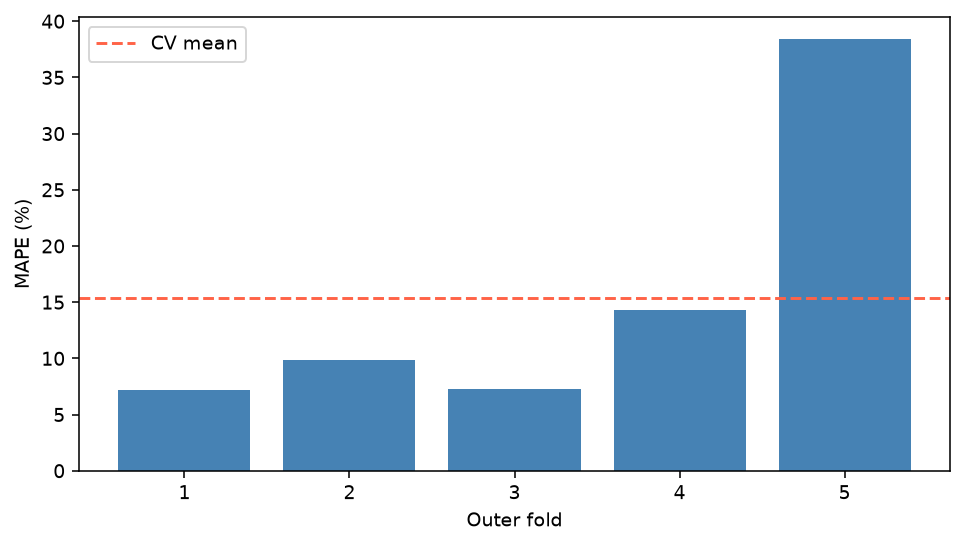

In [42]:
plt.figure(figsize=(7, 4))
plt.bar(fold_results['fold'], fold_results['MAPE (%)'], color='steelblue')
plt.axhline(train_cv_mape, color='tomato', linestyle='--', label='CV mean')
plt.xlabel('Outer fold')
plt.ylabel('MAPE (%)')
plt.legend()
plt.tight_layout()
plt.show()


# 10. 최종 후보 선택 및 학습
## 10-1. 개발 29개 전체에서 후보 선택

9단계는 선택 과정의 성능 확인이었다.
이제 개발 29개 전체에서 같은 안쪽 3-fold 선택을 하고 최종 모델을 학습한다.
Valid 7개는 합치지 않는다. Batch 2·3도 학습에 넣지 않는다.


In [43]:
selection_folds = make_group_folds(train, 3, stage='final-selection-CV')
final_search = make_search(selection_folds)
final_search.fit(train, train[TARGET])

chosen = describe_choice(final_search.best_params_)
selection_mape = -final_search.best_score_ * 100
best_model = final_search.best_estimator_
print('선택 결과:', chosen)
print(f'선택용 CV: {selection_mape:.2f}% (Train CV와 다름)')


선택 결과: {'family': 'SVR', 'feature_set': 'Variance only', 'features': ['dq_log_variance'], 'target_transform': 'log', 'hyperparameters': {'C': 1, 'epsilon': 0.01, 'gamma': 0.1}}
선택용 CV: 8.30% (Train CV와 다름)


## 10-2. 모델별 비교 표

각 후보의 선택용 CV를 표로 만든다.
가족별 최저 점수를 비교할 때 입력과 설정이 다를 수 있다는 점도 함께 확인한다.


In [44]:
candidate_rows = []
cv_results = final_search.cv_results_
for i, params in enumerate(cv_results['params']):
    row = describe_choice(params)
    row['features'] = ' | '.join(row['features'])
    row['hyperparameters'] = json.dumps(row['hyperparameters'], sort_keys=True)
    row['selection_cv_mape_pct'] = -cv_results['mean_test_score'][i] * 100
    row['selected'] = i == final_search.best_index_
    candidate_rows.append(row)

candidates = pd.DataFrame(candidate_rows).sort_values(
    'selection_cv_mape_pct', kind='stable'
).reset_index(drop=True)
family_best = candidates.groupby('family', sort=False).head(1)
family_best[['family', 'feature_set', 'target_transform', 'selection_cv_mape_pct']].round(3)


,family,feature_set,target_transform,selection_cv_mape_pct
0,SVR,Variance only,log,8.298
2,ElasticNet,Charging + band gap,log,8.710
6,Ridge,Charging + band gap,log,9.178
48,RandomForestRegressor,Charging + band gap,log,10.778


learning-cell-88-display:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


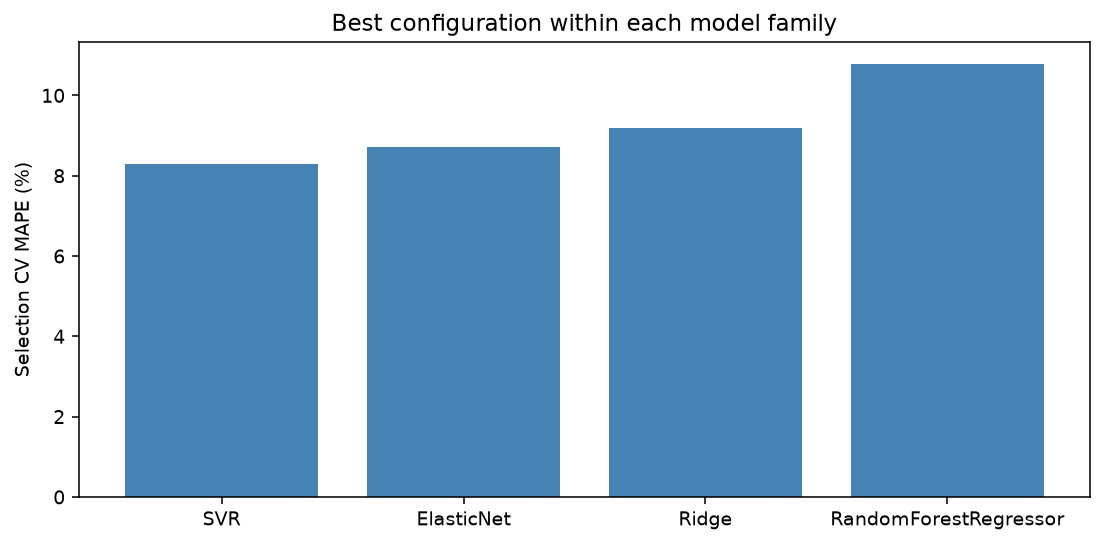

In [45]:
plt.figure(figsize=(8, 4))
plt.bar(family_best['family'], family_best['selection_cv_mape_pct'], color='steelblue')
plt.ylabel('Selection CV MAPE (%)')
plt.title('Best configuration within each model family')
plt.tight_layout()
plt.show()


## 10-3. 파생변수가 도움이 되었는지 확인

같은 SVR·로그 타깃에서 입력 조합별로 가장 좋은 설정을 비교한다.
하이퍼파라미터는 조합마다 선택하므로 한 변수만 바꾼 인과 실험은 아니다.
그래도 **어떤 입력 조합으로 모델을 만들지** 결정하는 근거가 된다.


In [46]:
svr_log = candidates[
    (candidates['family'] == 'SVR') & (candidates['target_transform'] == 'log')
]
feature_comparison = svr_log.groupby('feature_set', sort=False).head(1)
feature_comparison = feature_comparison.set_index('feature_set').loc[list(FEATURE_SETS)]
feature_comparison[['features', 'selection_cv_mape_pct']].round(3)


,features,selection_cv_mape_pct
feature_set,,
Charging only,C1 | C2 | SOC_switch | mean_chargetime,11.590
Variance only,dq_log_variance,8.298
Charging + variance,C1 | C2 | SOC_switch | mean_chargetime | dq_log_variance,11.378
Charging + band gap,C1 | C2 | SOC_switch | mean_chargetime | dq_band_gap,12.191
Charging + both,C1 | C2 | SOC_switch | mean_chargetime | dq_log_variance | dq_band_gap,11.904


learning-cell-91-display:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


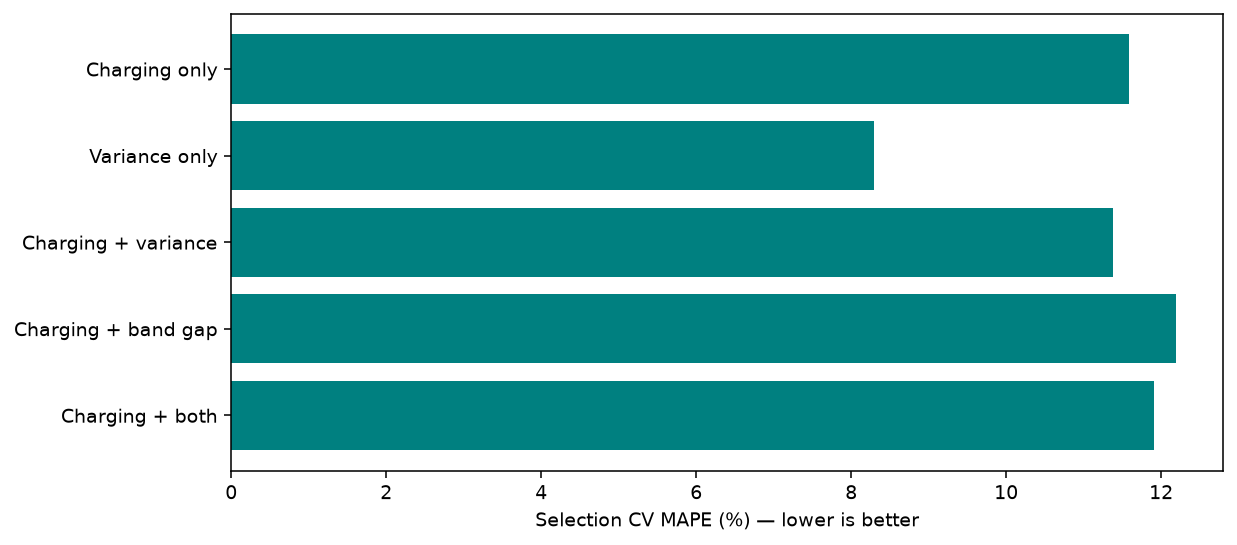

In [47]:
plt.figure(figsize=(9, 4))
plt.barh(feature_comparison.index, feature_comparison['selection_cv_mape_pct'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Selection CV MAPE (%) — lower is better')
plt.tight_layout()
plt.show()


### 변수 선택 해석 — 만든 이유와 실제 결과 연결

로그 분산은 초기 변화의 불균일성이 수명 예측에 도움이 되는지 확인하려고 만들었다.
충전 조건만 사용한 경우 CV MAPE는 11.59%, 기본 변수에 로그 분산을 추가하면 11.38%였다.
로그 분산 하나만 사용하면 8.30%로 더 낮았다. 따라서 이번 후보 비교에서는 로그 분산을 단일 입력으로 선택했다.

전압 구간 차이는 전체 분산이 놓치는 구간별 정보를 보완하려고 만들었다.
하지만 기본 변수에 이 값을 추가한 SVR은 12.19%, 기본 변수에 두 파생변수를 모두 추가한 SVR은 11.90%였다.
이번 SVR·로그 타깃 비교에서는 추가 이득을 확인하지 못하여 최종 입력에서 제외했다.
이는 다른 모델에서도 항상 무의미하다는 뜻은 아니다.

각 입력 조합의 하이퍼파라미터도 따로 선택했으므로, 이 표는 변수의 순수한 인과 효과를 증명하는 실험이 아니다.
**만든 이유 → 개발 자료에서 검증 → 최종 사용 여부 결정**이라는 흐름으로 해석한다.
선택용 CV 8.30%는 최종 Test 성능이 아니며, Batch 2 Test는 28.08%였다.


## 10-4. Test 전에 모델 고정

`refit=True` 덕분에 최종 설정으로 개발 29개 전체를 학습한 모델이 `best_model`에 들어 있다.
이를 저장한 후 Valid/Test를 예측한다. 이 이후 평가 점수로 입력·설정을 바꾸지 않는다.
이번 실행은 이전 실험을 설명하기 위한 재현이며, 과거 EDA·Test 결과를 이미 본 이력이 있다.


In [48]:
model_path = SAVE_DIR / 'best-model.joblib'
joblib.dump(best_model, model_path)
model_hash = hashlib.sha256(model_path.read_bytes()).hexdigest()
lock_record = {
    'chosen': chosen,
    'fit_cells': train['cell_id'].tolist(),
    'selection_cv_mape_pct': selection_mape,
    'model_sha256': model_hash,
    'stage': 'before-evaluation',
    'purpose': 'learning replay of the original experiment'
}
(SAVE_DIR / 'selection-lock.json').write_text(
    json.dumps(lock_record, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('고정한 모델:', model_path)


고정한 모델: /Users/jang/Documents/Codex/2026-10-01/goe/outputs/DAY2-learning/best-model.joblib


# 11. Valid / Test 평가
## 11-1. 새로운 셀의 예측값 만들기

지금은 `predict`만 한다. **fit은 하지 않는다.**
Pipeline이 학습 때 정한 입력 선택·대치·표준화를 적용하고 로그 예측을 역변환한다.
결과 표에는 식별을 위해 ID와 배치를 붙이지만 이 값은 모델 입력으로 선택되지 않는다.


In [49]:
evaluation_frames = {'Valid': valid, 'Test': test, 'Batch3-additional': test3}
prediction_frames = []
evaluation_scores = {}

for partition, frame in evaluation_frames.items():
    predicted = best_model.predict(frame)
    score = mape_percent(frame[TARGET], predicted)
    evaluation_scores[partition] = score

    result = frame[['cell_id', 'batch', 'cycle_life']].copy()
    result['partition'] = partition
    result['prediction'] = predicted
    result['ape_pct'] = abs(result['prediction'] - result[TARGET]) / result[TARGET] * 100
    prediction_frames.append(result)
    print(f'{partition}: {len(frame)}개, MAPE {score:.2f}%')

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions.head()


Valid: 7개, MAPE 11.87%
Test: 39개, MAPE 28.08%
Batch3-additional: 40개, MAPE 18.85%


,cell_id,batch,cycle_life,partition,prediction,ape_pct
0,b1c5,1,1074.0,Valid,847.241926,21.113415
1,b1c6,1,636.0,Valid,787.506843,23.821831
2,b1c7,1,870.0,Valid,811.398204,6.735839
3,b1c38,1,617.0,Valid,596.308928,3.353496
4,b1c39,1,625.0,Valid,630.742707,0.918833


## 11-2. 과제 Performance Reporting 표 만들기

MAPE는 %, Gap은 %p다. 첨부 양식의 Gap 이름은 유지하되
**뒤 평가에서 오차가 커지면 양수**가 되도록 계산식을 비고에 명시한다.
Train은 9단계의 중첩 CV 평균이며 7단계 학습 오차나 10단계 선택용 CV가 아니다.

Train-Valid는 `Valid − Train`, Valid-Test는 `Test − Valid`, Target-Test는 `Test − 9.1`이다.
**Train은 선택 과정의 CV, Valid·Test는 고정 모델의 평가이므로 Gap은 경고 신호로 해석하고 하나의 모델에서 과적합만 측정한 값으로 단정하지 않는다.**


In [50]:
valid_mape = evaluation_scores['Valid']
test_mape = evaluation_scores['Test']
test3_mape = evaluation_scores['Batch3-additional']
performance = pd.DataFrame([
    ['Train (Batch 1 CV)', '', train_cv_mape, '바깥 5-fold 중첩 그룹 CV 평균'],
    ['Valid (Batch 1 Hold-out)', '', valid_mape, '고정 Hold-out 7개'],
    ['Test (Batch 2)', '', test_mape, '고정 모델; 39개'],
    ['', 'Gap (Train-Valid)', valid_mape - train_cv_mape, 'Valid − Train; %p'],
    ['', 'Gap (Valid-Test)', test_mape - valid_mape, 'Batch 2 − Valid; %p'],
    ['', 'Gap (Target-Test)', test_mape - TARGET_MAPE, 'Batch 2 − 9.1; %p'],
    ['Test (Batch 3)', '', test3_mape, '동일 모델; 40개'],
    ['', 'Gap (Batch2-Batch3)', test3_mape - test_mape, 'Batch 3 − Batch 2; %p'],
    ['', 'Gap (Target-Test)', test3_mape - TARGET_MAPE, 'Batch 3 − 9.1; %p']
], columns=['구분', '추가 비교', 'MAPE (%)', '비고'])
performance.round(2)


,구분,추가 비교,MAPE (%),비고
0,Train (Batch 1 CV),,15.40,바깥 5-fold 중첩 그룹 CV 평균
1,Valid (Batch 1 Hold-out),,11.87,고정 Hold-out 7개
2,Test (Batch 2),,28.08,고정 모델; 39개
3,,Gap (Train-Valid),-3.53,Valid − Train; %p
4,,Gap (Valid-Test),16.21,Batch 2 − Valid; %p
5,,Gap (Target-Test),18.98,Batch 2 − 9.1; %p
6,Test (Batch 3),,18.85,동일 모델; 40개
7,,Gap (Batch2-Batch3),-9.23,Batch 3 − Batch 2; %p
8,,Gap (Target-Test),9.75,Batch 3 − 9.1; %p


# 12. 결과 시각화와 해석
## 12-1. 실제 수명과 예측 수명 비교

점이 대각선에 가까울수록 잘 맞는다. 대각선 아래는 실제보다 작게 예측한 경우다.
성능 표와 함께 어느 수명 구간에서 오차가 커지는지 확인한다.


learning-cell-100-display:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


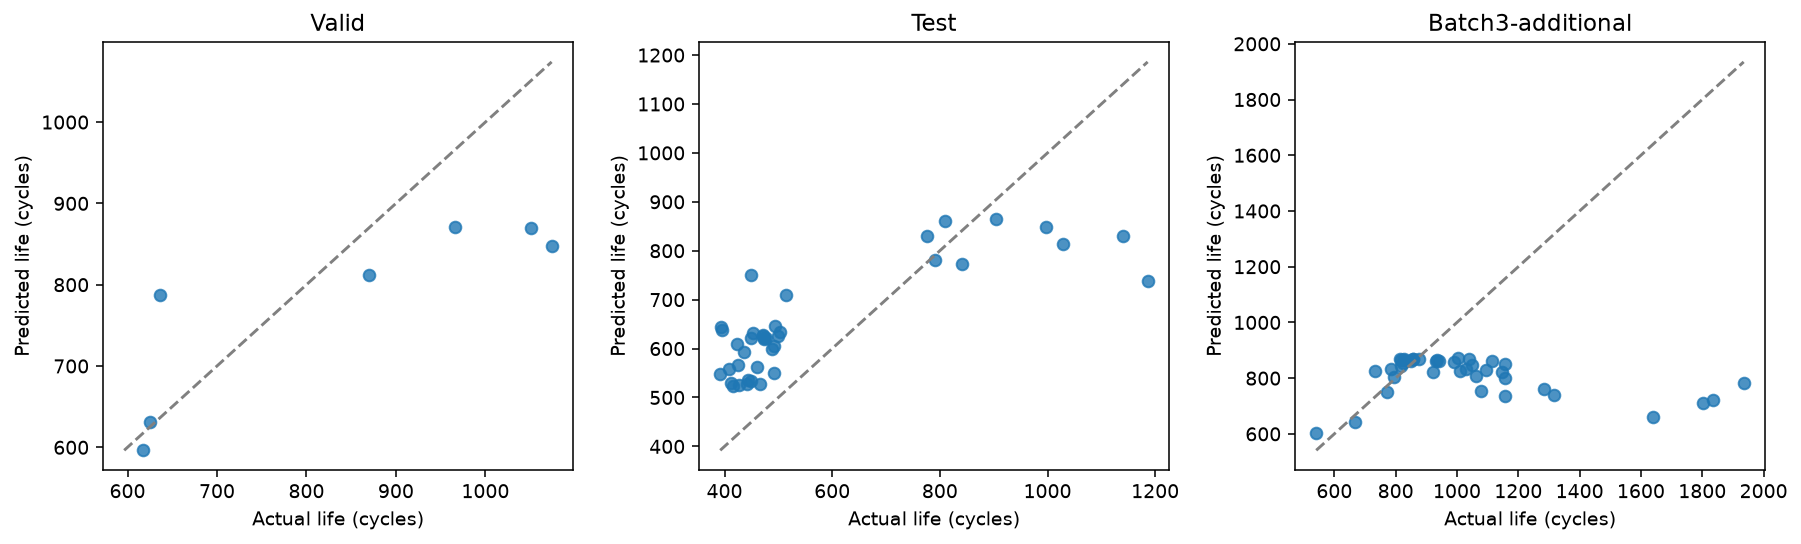

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (partition, frame) in zip(axes, predictions.groupby('partition', sort=False)):
    ax.scatter(frame['cycle_life'], frame['prediction'], alpha=.8)
    low = min(frame['cycle_life'].min(), frame['prediction'].min())
    high = max(frame['cycle_life'].max(), frame['prediction'].max())
    ax.plot([low, high], [low, high], '--', color='gray')
    ax.set(title=partition, xlabel='Actual life (cycles)', ylabel='Predicted life (cycles)')
plt.tight_layout()
plt.show()


## 12-2. SVR이 학습한 예측 곡선 보기

앞 그림의 대각선은 `실제 수명 = 예측 수명`이라는 **정답 기준선**이었다.
이번에는 가로축을 최종 입력인 **ΔQ 로그 분산**, 세로축을 **예측 수명**으로 두고
SVR이 어떤 관계를 학습했는지 직접 본다.

입력 값을 작은 간격으로 만들고 고정한 `best_model.predict`에 넣는다.
모델을 다시 학습하지 않는다. 이 모델은 최종 입력이 하나라 곡선으로 나타낼 수 있다.
전처리·표준화와 `exp` 역변환은 저장된 Pipeline이 수행하므로 여기서 다시 하지 않는다.

- 파란 점: 학습에 사용한 Batch 1 개발 셀 29개의 실제 수명.
- 주황색 선: 각 입력 값에서 모델이 예측한 수명. 정답선이나 점을 연결한 선이 아니다.
- 배경 표시와 실선: 개발 자료의 **입력 값 범위**. 이전의 실제 수명 범위와 구분한다.
- 점선: 개발 입력 범위 밖에서도 같은 모델로 예측한 값. 이 구간을 잘 맞힌다는 뜻은 아니다.

표시 구간은 모델 대상 115개 셀의 입력 범위를 사용한다. 이는 그림의 범위만 정하며
Test 수명으로 모델을 조정하지 않는다. 이 그림만으로 새 셀의 성능을 판단할 수는 없다.


In [ ]:
# 실제 입력 값 사이를 촘촘하게 채워 모델의 예측 곡선을 만든다.
curve_feature = 'dq_log_variance'
assert chosen['features'] == [curve_feature]
curve_min = data[curve_feature].min()
curve_max = data[curve_feature].max()
curve_x = np.linspace(curve_min, curve_max, 500)
curve_input = pd.DataFrame({curve_feature: curve_x})
curve_prediction = best_model.predict(curve_input)  # 원래 사이클 수 단위

train_x_min = train[curve_feature].min()
train_x_max = train[curve_feature].max()
curve_in_train = (curve_x >= train_x_min) & (curve_x <= train_x_max)
print(f'개발 입력 범위: {train_x_min:.3f} ~ {train_x_max:.3f}')


개발 입력 범위: -4.147 ~ -3.350


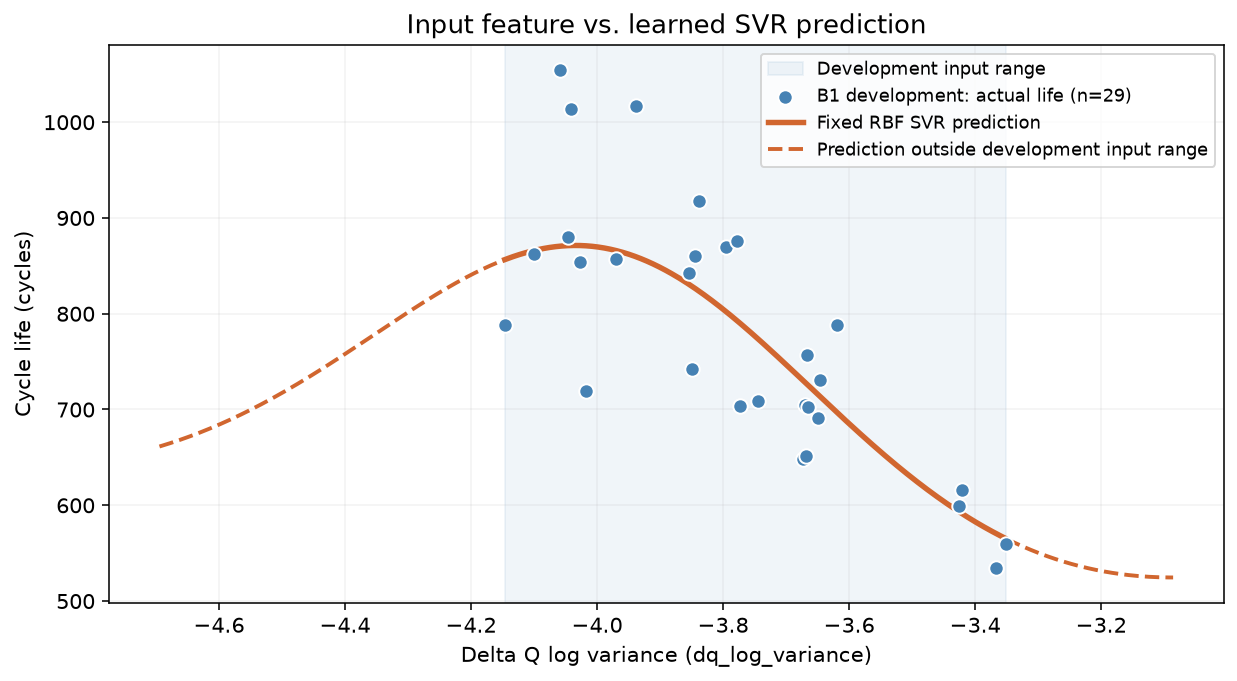

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(train_x_min, train_x_max, color='steelblue', alpha=.08,
           label='Development input range')
ax.scatter(train[curve_feature], train[TARGET], color='steelblue',
           edgecolor='white', s=55, zorder=3, label='B1 development: actual life (n=29)')
ax.plot(curve_x, np.where(curve_in_train, curve_prediction, np.nan),
        color='#d1662f', lw=2.8, label='Fixed RBF SVR prediction')
ax.plot(curve_x, np.where(~curve_in_train, curve_prediction, np.nan),
        color='#d1662f', lw=2, ls='--', label='Prediction outside development input range')
ax.set(xlabel='Delta Q log variance (dq_log_variance)',
       ylabel='Cycle life (cycles)', title='Input feature vs. learned SVR prediction')
ax.legend(fontsize=9)
ax.grid(alpha=.15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'svr-prediction-curve.png', dpi=170, bbox_inches='tight')
plt.show()


### 곡선을 어떻게 해석할까?

주황색 선이 입력에 따라 휘어지는 것을 볼 수 있다. 이것이 RBF SVR의 실제 예측 관계다.
비선형 모델이라고 모든 구간에서 크게 휘어야 하는 것은 아니다.
개발 입력 범위에서는 초기 변화가 큰 쪽에서 더 짧은 수명을 예측하는 경향을 보인다.
범위 밖에서 선이 평평해지거나 방향이 바뀌는 부분은 학습 자료가 부족한 구간이다.
이를 배터리의 물리 법칙으로 해석하면 안 된다. 원래 단위의 이 곡선에는 로그 타깃을
`exp`로 되돌린 효과도 포함되어 있다.

점과 선의 차이는 여기서는 **학습 셀의 오차**다. 새 셀의 성능은 별도의 CV·Valid·Test로 확인한다.


## 12-3. Batch 2에서 큰 오차 확인

예측 후 오차가 큰 셀을 살펴보는 진단이다. 성능을 높이려고 이 셀을 빼면 안 된다.


In [52]:
test_results = predictions[predictions['partition'] == 'Test']
test_results.sort_values('ape_pct', ascending=False).head(5).round(2)


,cell_id,batch,cycle_life,partition,prediction,ape_pct
25,b2c18,2,449.0,Test,751.13,67.29
13,b2c6,2,393.0,Test,644.44,63.98
22,b2c15,2,396.0,Test,636.95,60.85
9,b2c2,2,424.0,Test,608.67,43.56
34,b2c29,2,452.0,Test,632.70,39.98


## 12-4. 개발 수명 범위와 평가 오차

개발 자료는 534~1,054사이클이었다. 평가 셀의 실제 수명이 이 범위를 벗어나는지 확인한다.
**실제 수명은 예측할 때 모르는 y**다. 따라서 이 구분은 결과 해석용이고 X에 넣거나
범위 밖 셀을 제거하는 기준으로 쓰지 않는다.


In [53]:
life_min = train[TARGET].min()
life_max = train[TARGET].max()
predictions['outside_train_life_range'] = ~predictions[TARGET].between(life_min, life_max)
range_diagnosis = predictions.groupby(
    ['partition', 'outside_train_life_range'], sort=False
).agg(cells=('cell_id', 'size'), MAPE_pct=('ape_pct', 'mean'))
print('개발 수명 범위:', life_min, '~', life_max)
range_diagnosis.round(2)


개발 수명 범위: 534.0 ~ 1054.0


cells  MAPE_pct
partition         outside_train_life_range                 
Valid             True                          1     21.11
                  False                         6     10.33
Test              True                         32     32.28
                  False                         7      8.90
Batch3-additional False                        26      7.91
                  True                         14     39.17

### 결과를 어떻게 설명할까?

- Batch 2 MAPE 28.08%는 과제 기준 9.1%보다 18.98%p 높다. **목표에 도달하지 못했다.**
- 선택용 CV 8.30%와 Test의 차이는 개발 자료에서 선택한 모델이 새 배치에서 그대로 잘 맞지는 않았다는 뜻이다.
- Batch 2에는 개발 자료보다 수명이 짧은 셀이 많고, Batch 3에는 장수명 셀도 있다.
  수명 범위 차이는 원인 후보지만 유일한 원인이라고 확정할 수 없다.
- Batch 3 18.85%는 Batch 2보다 낮지만 과제 기준에는 미달한다.
- Valid 7개와 개발 29개는 작은 표본이다. Valid가 Train보다 낮다고 과적합이 없다고 결론 내리지 않는다.
- 최적 모델은 **이번 후보·설정 중 개발 CV가 가장 낮은 모델**이라는 뜻이다.
- DAY 1에서 다른 배치의 EDA를 이미 보았다. 완전히 블라인드한 Test 또는 논문 전체 실험 재현이라고 주장하지 않는다.


## 12-5. 기존 결과와 일치 확인 및 저장

읽기 쉽게 코드를 나누면서 기존 계산을 바꾸지 않았는지 확인한다.
기존 기록이 없는 별도 실습 폴더에서는 비교 점검을 건너뛰고 새 결과를 저장한다.
점검은 결과를 바꾸는 학습 단계가 아니다.


In [54]:
reference_path = DATA_DIR / 'DAY2-results-summary.json'
if reference_path.exists():
    reference = json.loads(reference_path.read_text())
    assert chosen == reference['chosen']
    np.testing.assert_allclose(train_cv_mape, reference['train_cv_mape_pct'], atol=1e-10, rtol=0)
    for partition, score in evaluation_scores.items():
        np.testing.assert_allclose(
            score, reference['evaluation'][partition]['mape_pct'], atol=1e-10, rtol=0
        )
    print('선택 모델, Train CV, Valid, Batch 2, Batch 3가 기존 결과와 일치합니다.')

candidates.to_csv(SAVE_DIR / 'candidate-results.csv', index=False)
predictions.to_csv(SAVE_DIR / 'evaluation-predictions.csv', index=False)
performance.to_csv(SAVE_DIR / 'performance-report.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(split_audits).to_csv(SAVE_DIR / 'split-audit.csv', index=False)
fold_results.to_csv(SAVE_DIR / 'nested-cv-folds.csv', index=False)
print('실습 결과 저장:', SAVE_DIR)


선택 모델, Train CV, Valid, Batch 2, Batch 3가 기존 결과와 일치합니다.
실습 결과 저장: /Users/jang/Documents/Codex/2026-10-01/goe/outputs/DAY2-learning


# 13. 학습 정리와 Self-Practice

## 자주 쓰는 코드 읽기

| 표현 | 뜻 |
|---|---|
| `df[columns]` | 사용할 열 선택 |
| `df[조건]` | 조건에 맞는 행 선택 |
| `iloc[행 번호]` | CV가 지정한 행 꺼내기 |
| `fit` | 학습 데이터로 기준·모델 계산 |
| `transform` | 기존 기준으로 값 변환 |
| `predict` | 학습된 모델로 예측 |
| `Pipeline` | 전처리와 모델을 한 순서로 묶기 |
| `GroupKFold` | 같은 프로토콜을 함께 나누는 CV |
| `GridSearchCV` | 여러 설정을 CV로 비교하고 선택 |

## 직접 해볼 것

1. 7단계의 모델을 Ridge로 바꾸고 `fit → predict → 평가`를 작성해 본다. 우선 개발 데이터에서만 연습한다.
2. `C`, `epsilon`, `gamma` 중 하나를 바꿨을 때 무엇이 달라질지 설명한다.
3. 10-3단계에서 로그 분산만 쓴 경우와 두 변수를 쓴 경우를 자신의 말로 비교한다.
4. 학습 오차·선택 CV·Train CV·Valid·Test의 역할을 각각 한 문장으로 써 본다.
5. 범위 밖 셀을 빼면 MAPE가 낮아져도 최종 Test 성능으로 제출하면 안 되는 이유를 설명한다.

새 실험을 한다면 별도 파일로 저장하고 개발 자료에서 선택한다.
이미 본 Test를 반복해서 보고 설정을 고른 결과는 최초 최종 평가와 구분한다.

## 참고 자료

- 구성 참고: 사용자가 제공한 `/Users/jang/Downloads/ML_5)_Timeseries.ipynb`
- [Pipeline 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
- [타깃 변환 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)
- [GroupKFold 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html)
- [MAPE 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html)
- [Severson et al., Nature Energy 2019](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)
